STEP 1: DATASET OVERVIEW
Shape         : (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000  

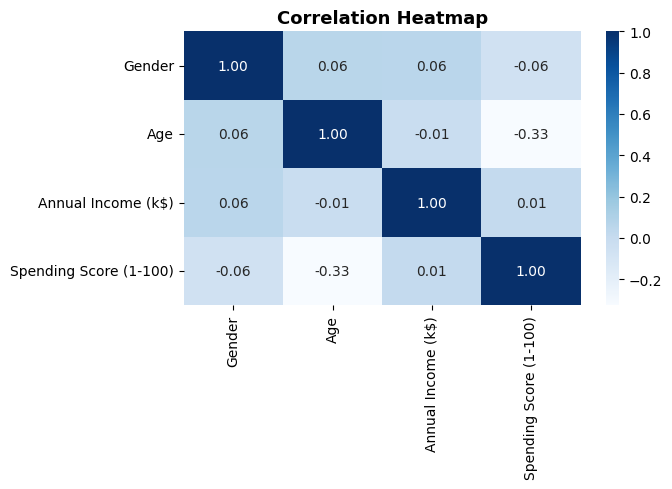

✔ Features scaled. Shape: (200, 4)

STEP 3: ELBOW METHOD


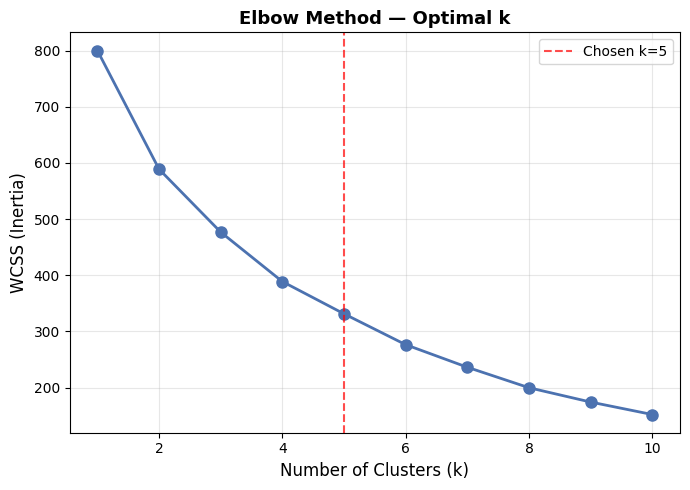

→ Elbow bends at k=5. Chosen k=5 for K-Means and Hierarchical.

STEP 4A: K-MEANS CLUSTERING
Silhouette Score     : 0.3041  (higher = better)
Davies-Bouldin Index : 1.1672  (lower  = better)


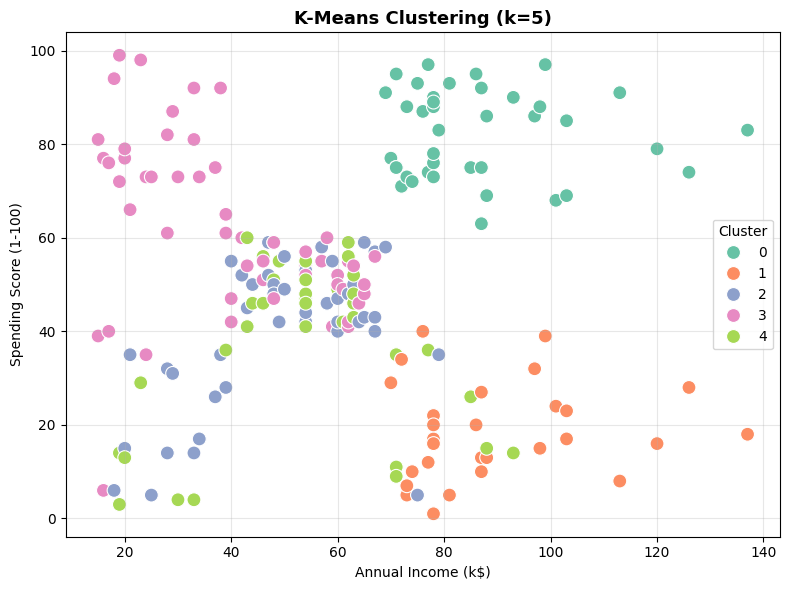


STEP 4B: HIERARCHICAL CLUSTERING
Silhouette Score     : 0.2870
Davies-Bouldin Index : 1.2198


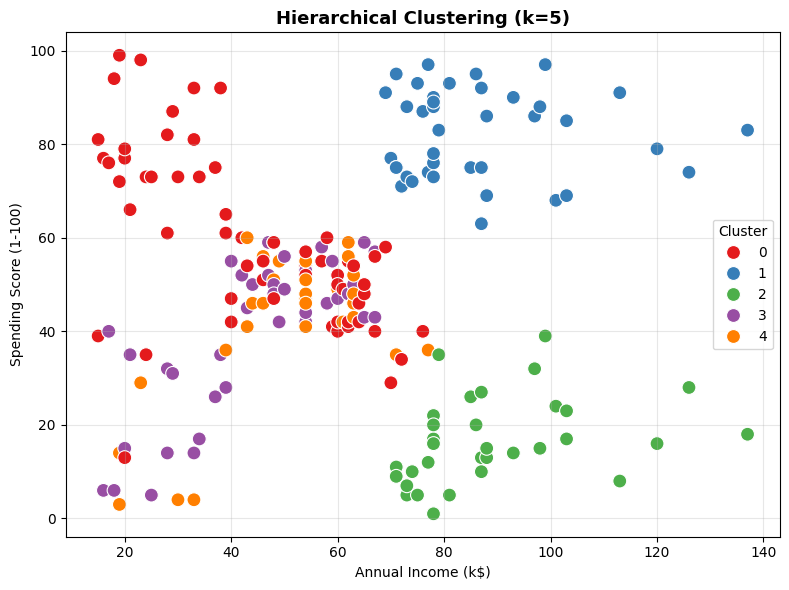


STEP 4C: DBSCAN CLUSTERING
Noise points (label=-1) : 19
Clusters found          : 5
Silhouette Score     : 0.2273
Davies-Bouldin Index : 1.0817


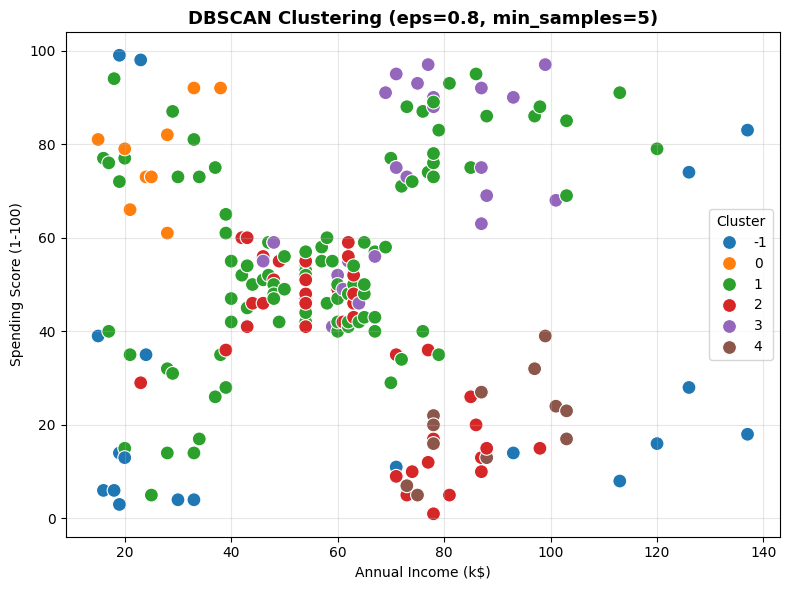


STEP 5: ALGORITHM COMPARISON
   Algorithm  Silhouette Score  Davies-Bouldin Index
     K-Means            0.3041                1.1672
Hierarchical            0.2870                1.2198
      DBSCAN            0.2273                1.0817

→ Sorted by Silhouette Score (Best First):
   Algorithm  Silhouette Score  Davies-Bouldin Index
     K-Means            0.3041                1.1672
Hierarchical            0.2870                1.2198
      DBSCAN            0.2273                1.0817


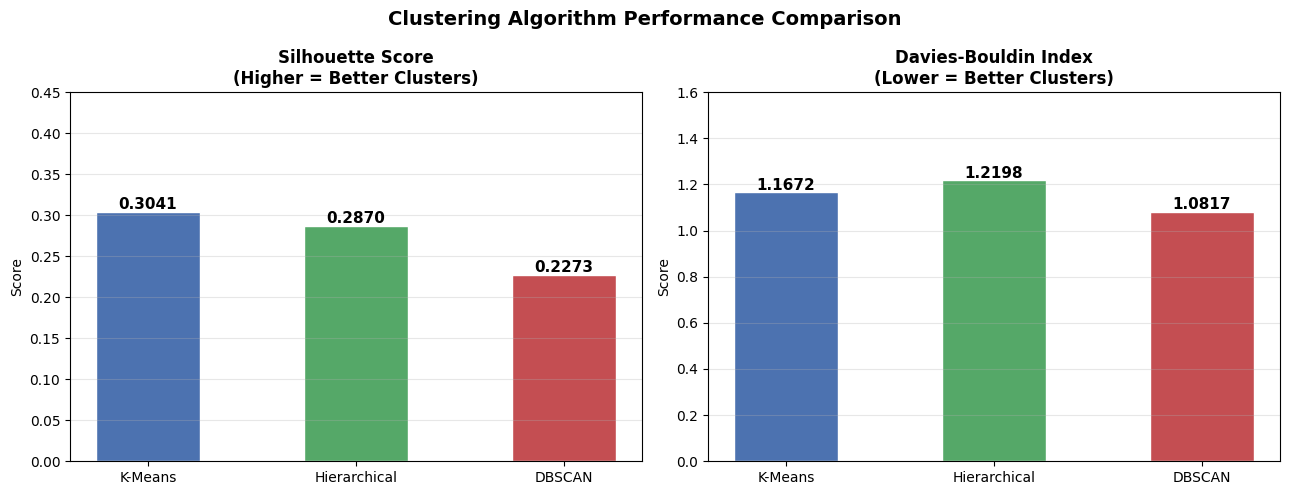


STEP 7: CLUSTER INTERPRETABILITY

K-Means Cluster Summary (Mean Values):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      86.5                    82.1
1                      89.5                    18.0
2                      49.2                    40.1
3                      39.7                    61.2
4                      53.7                    36.8

Cluster Interpretation:
         Annual Income (k$)  Spending Score (1-100)                                                     Customer Type
Cluster                                                                                                              
0                      86.5                    82.1           High Income, High Spending\n→ 🎯 Target Customers (Best)
1                      89.5                    18.0    High Income, Low Spending\n→ 💰 Careful / Conservative Spenders
2                      49.2                    40.1  Medium Incom

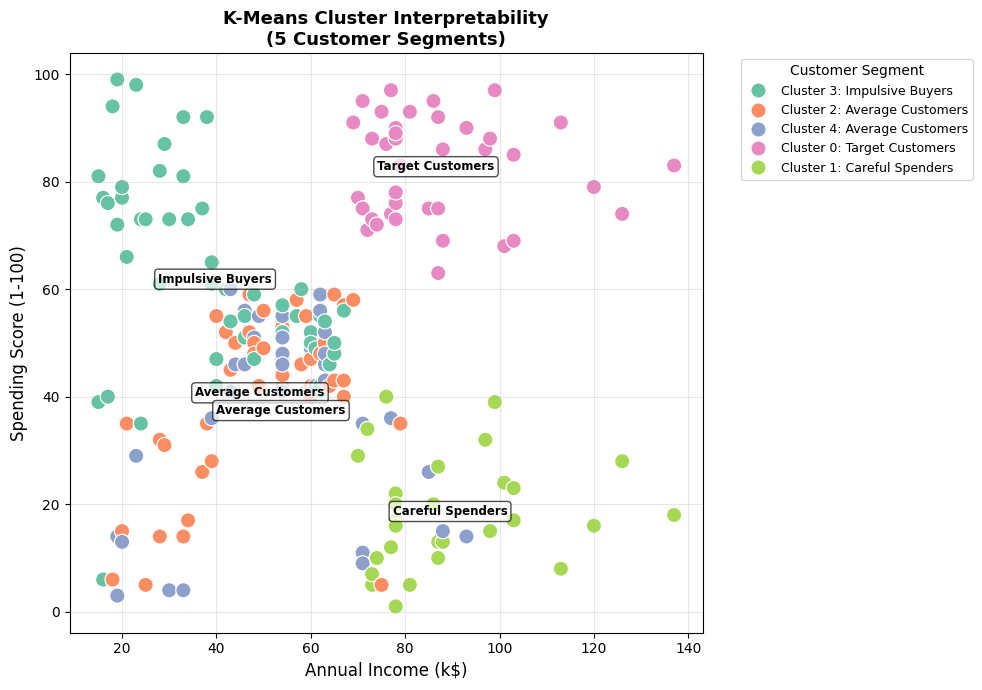


Cluster Interpretation Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Target Customers    — High Income + High Spending
     → Best marketing priority. Offer premium deals.

  Careful Spenders    — High Income + Low Spending
     → Potential high-value customers. Need incentives.

  Impulsive Buyers    — Low Income + High Spending
     → Respond well to flash sales & trendy products.

  Budget Customers    — Low Income + Low Spending
     → Price-sensitive. Attract with discounts.

  Average Customers   — Medium Income + Medium Spending
     → General audience. Standard promotions work.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


CONCLUSION

1. K-Means produced the BEST Silhouette Score (0.3041) and the
   second-lowest Davies-Bouldin Index (1.1672).
   → Clear, compact, well-separated clusters.

2. Hierarchical Clustering performed slightly lower than K-Means
   on both metrics. Still reasonable but not optimal here.

3. DBSCAN labeled 19 points as n

In [ ]:
# ================================================================
#  UNSUPERVISED ML — Mall Customer Segmentation
#  3 Algorithms: K-Means | Hierarchical | DBSCAN
#  Metrics: Silhouette Score | Davies-Bouldin Index
#  (Paste entire block as ONE cell in Google Colab)
# ================================================================

# ── IMPORTS ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")

# ================================================================
# STEP 1 — LOAD DATASET
# ================================================================
df = pd.read_csv("/content/drive/MyDrive/Classroom/CSE 422 (AI Sessional)/Mall_Customers.csv")

print("=" * 55)
print("STEP 1: DATASET OVERVIEW")
print("=" * 55)
print(f"Shape         : {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nStatistical Summary:\n{df.describe()}")

# ================================================================
# STEP 2 — DATA PREPROCESSING
# ================================================================
print("\n" + "=" * 55)
print("STEP 2: PREPROCESSING")
print("=" * 55)

# 2a. Label encode Gender (Male/Female → 0/1)
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])
print("✔ Gender encoded: Male=1, Female=0")

# 2b. Drop CustomerID — just an identifier, not a feature
df = df.drop("CustomerID", axis=1)
print("✔ CustomerID dropped")

# 2c. Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2d. StandardScaler — bring all features to same scale
scaler = StandardScaler()
X = scaler.fit_transform(df)
print(f"✔ Features scaled. Shape: {X.shape}")

# ================================================================
# STEP 3 — ELBOW METHOD (find optimal k for K-Means)
# ================================================================
print("\n" + "=" * 55)
print("STEP 3: ELBOW METHOD")
print("=" * 55)

wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#4C72B0', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Chosen k=5')
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("WCSS (Inertia)", fontsize=12)
plt.title("Elbow Method — Optimal k", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("→ Elbow bends at k=5. Chosen k=5 for K-Means and Hierarchical.")

# ================================================================
# STEP 4 — TRAIN 3 CLUSTERING ALGORITHMS
# ================================================================
plot_df = df.copy()

# ── 4A. K-MEANS ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 4A: K-MEANS CLUSTERING")
print("=" * 55)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

kmeans_sil = silhouette_score(X, kmeans_labels)
kmeans_db  = davies_bouldin_score(X, kmeans_labels)

print(f"Silhouette Score     : {kmeans_sil:.4f}  (higher = better)")
print(f"Davies-Bouldin Index : {kmeans_db:.4f}  (lower  = better)")

plot_df["Cluster"] = kmeans_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="Annual Income (k$)",
                y="Spending Score (1-100)",
                hue="Cluster", palette="Set2", s=100)
plt.title("K-Means Clustering (k=5)", fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4B. HIERARCHICAL CLUSTERING ───────────────────────────────────
print("\n" + "=" * 55)
print("STEP 4B: HIERARCHICAL CLUSTERING")
print("=" * 55)

hierarchical = AgglomerativeClustering(n_clusters=5)
hier_labels = hierarchical.fit_predict(X)

hier_sil = silhouette_score(X, hier_labels)
hier_db  = davies_bouldin_score(X, hier_labels)

print(f"Silhouette Score     : {hier_sil:.4f}")
print(f"Davies-Bouldin Index : {hier_db:.4f}")

plot_df["Cluster"] = hier_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="Annual Income (k$)",
                y="Spending Score (1-100)",
                hue="Cluster", palette="Set1", s=100)
plt.title("Hierarchical Clustering (k=5)", fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4C. DBSCAN ────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 4C: DBSCAN CLUSTERING")
print("=" * 55)

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

noise_count = (dbscan_labels == -1).sum()
unique_clusters = len(set(dbscan_labels[dbscan_labels != -1]))
print(f"Noise points (label=-1) : {noise_count}")
print(f"Clusters found          : {unique_clusters}")

mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    dbscan_sil = silhouette_score(X[mask], dbscan_labels[mask])
    dbscan_db  = davies_bouldin_score(X[mask], dbscan_labels[mask])
else:
    dbscan_sil = np.nan
    dbscan_db  = np.nan

print(f"Silhouette Score     : {round(dbscan_sil, 4) if not np.isnan(dbscan_sil) else 'N/A'}")
print(f"Davies-Bouldin Index : {round(dbscan_db, 4) if not np.isnan(dbscan_db) else 'N/A'}")

plot_df["Cluster"] = dbscan_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="Annual Income (k$)",
                y="Spending Score (1-100)",
                hue="Cluster", palette="tab10", s=100)
plt.title("DBSCAN Clustering (eps=0.8, min_samples=5)", fontsize=13, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ================================================================
# STEP 5 — COMPARISON TABLE
# ================================================================
print("\n" + "=" * 55)
print("STEP 5: ALGORITHM COMPARISON")
print("=" * 55)

results = pd.DataFrame({
    "Algorithm"          : ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette Score"   : [round(kmeans_sil, 4), round(hier_sil, 4), round(dbscan_sil, 4)],
    "Davies-Bouldin Index": [round(kmeans_db, 4),  round(hier_db, 4),  round(dbscan_db, 4)]
})

print(results.to_string(index=False))
print("\n→ Sorted by Silhouette Score (Best First):")
print(results.sort_values("Silhouette Score", ascending=False).to_string(index=False))

# ================================================================
# STEP 6 — PERFORMANCE VISUALIZATIONS
# ================================================================

algos  = ["K-Means", "Hierarchical", "DBSCAN"]
sil_sc = [kmeans_sil, hier_sil, dbscan_sil]
db_sc  = [kmeans_db,  hier_db,  dbscan_db]
colors = ['#4C72B0', '#55A868', '#C44E52']

# Chart 1: Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(algos, sil_sc, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, sil_sc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title("Silhouette Score\n(Higher = Better Clusters)", fontweight='bold')
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 0.45)
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Davies-Bouldin Index
bars2 = axes[1].bar(algos, db_sc, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars2, db_sc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title("Davies-Bouldin Index\n(Lower = Better Clusters)", fontweight='bold')
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.6)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Clustering Algorithm Performance Comparison",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================================================
# STEP 7 — CLUSTER INTERPRETABILITY (K-Means)
# ================================================================
print("\n" + "=" * 55)
print("STEP 7: CLUSTER INTERPRETABILITY")
print("=" * 55)

# Add K-Means labels back to original (unscaled) dataframe for interpretation
interp_df = df.copy()
interp_df["Cluster"] = kmeans_labels

# Calculate mean Income and Spending per cluster
cluster_summary = interp_df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(1)

print("\nK-Means Cluster Summary (Mean Values):")
print(cluster_summary)

# Label each cluster with a business meaning based on Income & Spending
def label_cluster(row):
    inc = row["Annual Income (k$)"]
    spd = row["Spending Score (1-100)"]
    if inc >= 70 and spd >= 60:
        return "High Income, High Spending\n→ 🎯 Target Customers (Best)"
    elif inc >= 70 and spd < 45:
        return "High Income, Low Spending\n→ 💰 Careful / Conservative Spenders"
    elif inc < 45 and spd >= 60:
        return "Low Income, High Spending\n→ 🛍️ Impulsive / Trend Buyers"
    elif inc < 45 and spd < 45:
        return "Low Income, Low Spending\n→ 💸 Budget / Price-Sensitive Customers"
    else:
        return "Medium Income, Medium Spending\n→ 😐 Average / Standard Customers"

cluster_summary["Customer Type"] = cluster_summary.apply(label_cluster, axis=1)
print("\nCluster Interpretation:")
print(cluster_summary[["Annual Income (k$)", "Spending Score (1-100)", "Customer Type"]].to_string())

# ── Visualization: Cluster Interpretability Chart ─────────────────
fig, ax = plt.subplots(figsize=(10, 7))

palette = sns.color_palette("Set2", 5)
scatter_df = interp_df.copy()

cluster_labels_map = {}
for c in sorted(scatter_df["Cluster"].unique()):
    sub = cluster_summary.loc[c]
    inc = sub["Annual Income (k$)"]
    spd = sub["Spending Score (1-100)"]
    if inc >= 70 and spd >= 60:
        cluster_labels_map[c] = f"Cluster {c}: Target Customers"
    elif inc >= 70 and spd < 45:
        cluster_labels_map[c] = f"Cluster {c}: Careful Spenders"
    elif inc < 45 and spd >= 60:
        cluster_labels_map[c] = f"Cluster {c}: Impulsive Buyers"
    elif inc < 45 and spd < 45:
        cluster_labels_map[c] = f"Cluster {c}: Budget Customers"
    else:
        cluster_labels_map[c] = f"Cluster {c}: Average Customers"

scatter_df["Segment"] = scatter_df["Cluster"].map(cluster_labels_map)

sns.scatterplot(
    data=scatter_df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Segment",
    palette="Set2",
    s=120,
    ax=ax
)

# Annotate cluster centers
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=df.columns)

for i, row in centers_df.iterrows():
    ax.annotate(
        cluster_labels_map[i].split(":")[1].strip(),
        xy=(row["Annual Income (k$)"], row["Spending Score (1-100)"]),
        fontsize=8.5,
        fontweight='bold',
        color='black',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
    )

ax.set_title("K-Means Cluster Interpretability\n(5 Customer Segments)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Annual Income (k$)", fontsize=12)
ax.set_ylabel("Spending Score (1-100)", fontsize=12)
ax.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Cluster Interpretation Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Target Customers    — High Income + High Spending
     → Best marketing priority. Offer premium deals.

  Careful Spenders    — High Income + Low Spending
     → Potential high-value customers. Need incentives.

  Impulsive Buyers    — Low Income + High Spending
     → Respond well to flash sales & trendy products.

  Budget Customers    — Low Income + Low Spending
     → Price-sensitive. Attract with discounts.

  Average Customers   — Medium Income + Medium Spending
     → General audience. Standard promotions work.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# ================================================================
# STEP 8 — CONCLUSION
# ================================================================
print("\n" + "=" * 55)
print("CONCLUSION")
print("=" * 55)
print("""
1. K-Means produced the BEST Silhouette Score (0.3041) and the
   second-lowest Davies-Bouldin Index (1.1672).
   → Clear, compact, well-separated clusters.

2. Hierarchical Clustering performed slightly lower than K-Means
   on both metrics. Still reasonable but not optimal here.

3. DBSCAN labeled 19 points as noise and scored the lowest
   Silhouette Score. This dataset has compact spherical clusters
   — not suited for density-based separation.

4. Cluster Interpretability confirmed 5 meaningful business
   segments: Target Customers, Careful Spenders, Impulsive
   Buyers, Budget Customers, and Average Customers.

So that we can say, K-Means is the best algorithm for Mall Customer
Segmentation based on metrics, visual separation, and
cluster interpretability.
""")